# 01. EDA — Batch 1 / 2 / 3 비교

- 대상 : Batch 1 (2017-05-12, Train) · Batch 2 (2018-02-20, Test) · Batch 3 (2018-04-12, 추가 Test)
- 각 섹션 : 그래프·수치 → 끝에 `해석 / 시사점` 정리
- 전처리 : `src/preprocess.py` (raw .mat → 캐시), 피처 : `src/features.py`

In [1]:
import sys; sys.path.insert(0, '../src')
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from scipy.stats import ks_2samp, spearmanr
from sklearn.linear_model import LinearRegression

import features as F

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
FIG = Path('../results/figures'); FIG.mkdir(parents=True, exist_ok=True)
def save(fig, name): fig.savefig(FIG / f'{name}.png', dpi=120, bbox_inches='tight')

cells, summary, qdlin, vdlin, ids = F.load()
feats = F.build(cells, summary, qdlin, ids)
idx = {c: i for i, c in enumerate(ids)}

# 충전 정책 파싱 : C1(Q1%)-C2  → 0~80% SOC 이론 충전시간, 평균 C-rate
def parse_policy(p):
    m = re.match(r'([\d.]+)C\((\d+)%\)-([\d.]+)C', p)
    if not m: return pd.Series({'C1': np.nan, 'Q1': np.nan, 'C2': np.nan})
    return pd.Series({'C1': float(m[1]), 'Q1': float(m[2]), 'C2': float(m[3])})
feats = feats.join(feats.policy.apply(parse_policy))
feats['t80_min'] = 60 * (feats.Q1 / 100 / feats.C1 + (80 - feats.Q1) / 100 / feats.C2)
feats['crate_avg_0_80'] = 0.8 / (feats.t80_min / 60)

BATCHES = ['b1', 'b2', 'b3']
LABEL = {'b1': 'Batch 1 (train)', 'b2': 'Batch 2 (test)', 'b3': 'Batch 3 (extra test)'}
ok = feats[~feats.censored].copy()
ok['log_life'] = np.log10(ok.cycle_life)
norm, cmap = colors.LogNorm(ok.cycle_life.min(), ok.cycle_life.max()), cm.viridis_r

## 0. 데이터 품질 — 제외 대상 셀

- 제외 기준 : `censored` = 마지막 5사이클 QD 중앙값 > 0.90Ah 또는 cycle_life 결측 → **EOL(0.88Ah) 도달 전에 시험이 끝나 라벨이 실제 수명이 아님**
- 원출처 노트 (data.matr.io)
  - Batch 1 : 채널 1,2,3,5,6 (3.6C(80%), 4C(80%) 정책 = `b1c0~b1c4`)은 2017-06-30 배치로 이어서 시험됨 → 이 파일만으로는 실제 수명 알 수 없음
  - Batch 1 : 채널 13,19,21,22,31은 80% 도달 전 시험 종료
  - Batch 2 : 원출처 분류상 *Fig.4용 low-rate 데이터*. VarCharge / SLOWCYCLE 등 비표준 프로토콜 셀 포함

In [2]:
excl = feats[feats.censored][['batch', 'cell_id', 'policy', 'cycle_life', 'n_cycles', 'final_QD']]
display(excl)
pd.DataFrame({'total': feats.groupby('batch').size(), 'excluded': excl.groupby('batch').size(),
              'used': ok.groupby('batch').size()})

,batch,cell_id,policy,cycle_life,n_cycles,final_QD
0,b1,b1c0,3.6C(80%)-3.6C,1190.0,1189,1.026499
1,b1,b1c1,3.6C(80%)-3.6C,1179.0,1178,1.038700
2,b1,b1c2,3.6C(80%)-3.6C,1177.0,1176,1.043586
3,b1,b1c3,4C(80%)-4C,1226.0,1225,0.971356
4,b1,b1c4,4C(80%)-4C,1227.0,1226,1.021865
8,b1,b1c8,5.4C(40%)-3.6C,879.0,878,0.970365
10,b1,b1c10,5.4C(50%)-3C,906.0,905,0.962339
12,b1,b1c12,5.4C(50%)-3.6C,902.0,901,0.915049
13,b1,b1c13,5.4C(50%)-3.6C,897.0,896,0.925050
22,b1,b1c22,6C(30%)-3.6C,891.0,890,0.965279


,total,excluded,used
batch,,,
b1,46,10,36
b2,47,8,39
b3,46,2,44


In [3]:
# 시험 종료 기준 비교 : EOL 이후에도 사이클링을 계속했는가? (n_cycles - cycle_life)
(ok.n_cycles - ok.cycle_life).groupby(ok.batch).describe()[['mean', 'min', 'max']]

,mean,min,max
batch,,,
b1,-1.000000,-1.0,-1.0
b2,24.871795,15.0,66.0
b3,-1.000000,-1.0,-1.0


In [4]:
# 사이클 1 정의 : b1은 cycle 1 = 초기 C/10 저속 사이클(데이터 없음, QD=0) / b2·b3는 cycle 1부터 고속 사이클
first = summary[summary.cycle <= 3].merge(feats[['cell_id', 'batch']])
first.groupby(['batch', 'cycle']).QD.median().unstack().round(4)

cycle,1.0,2.0,3.0
batch,,,
b1,0.0000,1.0787,1.0796
b2,1.0920,1.0926,1.0951
b3,1.0646,1.0659,1.0665


In [5]:
# QD 이상값 (cycle>=2 에서 0.5Ah 미만 또는 1.2Ah 초과) 개수
s2 = summary[summary.cycle >= 2].merge(feats[['cell_id', 'batch']])
s2.assign(spike=(s2.QD < 0.5) | (s2.QD > 1.2)).groupby('batch').spike.agg(['sum', 'mean'])

,sum,mean
batch,,
b1,2,0.000052
b2,11,0.000410
b3,0,0.000000


In [6]:
# 라벨 기준 확인 : cycle_life 시점의 QD (세 배치 모두 0.88Ah 기준인가)
at = summary.merge(ok[['cell_id', 'batch', 'cycle_life']])
at[at.cycle.between(at.cycle_life - 2, at.cycle_life)].groupby('batch').QD.median().round(4)

batch
b1    0.8812
b2    0.8812
b3    0.8807
Name: QD, dtype: float64

> **해석 / 시사점**
>
> - 라벨을 믿을 수 없는 셀 제외 : B1 10 · B3 2(EOL 도달 전 시험 종료), B2 8(VarCharge·SLOWCYCLE 비표준 프로토콜, 수명 라벨 없음) → 사용 36 / 39 / 44
> - B2는 EOL 이후에도 15~66 사이클 더 시험했지만, cycle_life 시점 QD는 세 배치 모두 약 0.88Ah → 라벨 기준은 동일
> - B1만 cycle 1이 저속 사이클(데이터 없음) → B2·B3와 1사이클 어긋남 (영향은 섹션 3에서 확인)

## 1. Cycle Life 분포는 어떻게 생겼는가?

- Histogram (100 ~ 2,300), 장수명(>1,000) / 단수명(<500) 비율, 이상치 셀

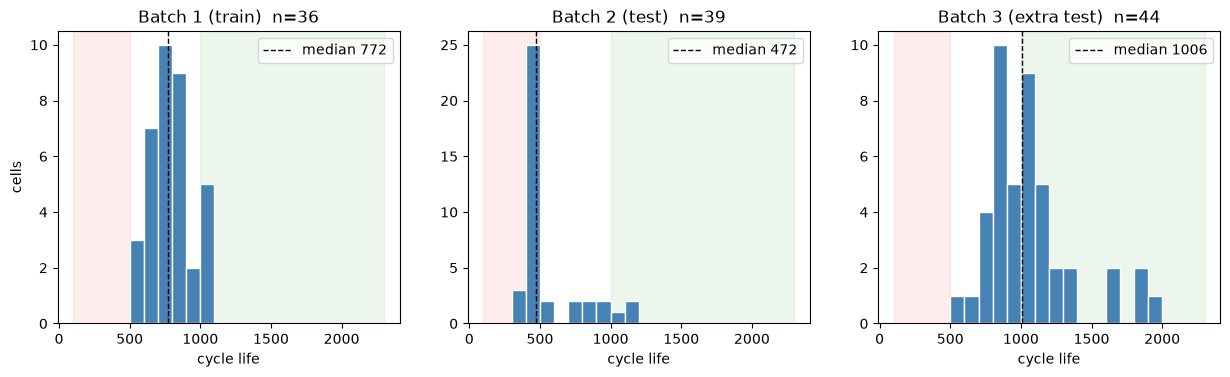

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharex=True)
bins = np.arange(100, 2400, 100)
for ax, b in zip(axes, BATCHES):
    g = ok[ok.batch == b]
    ax.axvspan(100, 500, color='red', alpha=.07); ax.axvspan(1000, 2300, color='green', alpha=.07)
    ax.hist(g.cycle_life, bins=bins, color='steelblue', edgecolor='white')
    ax.axvline(g.cycle_life.median(), color='k', ls='--', lw=1, label=f'median {g.cycle_life.median():.0f}')
    ax.set_title(f'{LABEL[b]}  n={len(g)}'); ax.set_xlabel('cycle life'); ax.legend()
axes[0].set_ylabel('cells')
save(fig, '1_cycle_life_hist')

In [8]:
def life_stats(l):
    return pd.Series({'n': len(l), 'mean': l.mean(), 'std': l.std(), 'min': l.min(), 'Q1': l.quantile(.25),
                      'median': l.median(), 'Q3': l.quantile(.75), 'max': l.max(), 'skew': l.skew(),
                      'long(>1000)%': (l > 1000).mean() * 100, 'short(<500)%': (l < 500).mean() * 100})
ok.groupby('batch').cycle_life.apply(life_stats).unstack().round(1)

,n,mean,std,min,Q1,median,Q3,max,skew,long(>1000)%,short(<500)%
batch,,,,,,,,,,,
b1,36.0,788.4,148.7,534.0,681.0,772.5,871.5,1074.0,0.3,13.9,0.0
b2,39.0,565.7,222.2,392.0,439.5,472.0,508.5,1186.0,1.6,7.7,71.8
b3,44.0,1059.7,313.9,541.0,828.0,1005.5,1155.2,1935.0,1.3,52.3,0.0


In [9]:
# IQR 기준 이상치 + 배치별 최단수명 3개
def iqr_out(g):
    q1, q3 = g.cycle_life.quantile([.25, .75]); r = q3 - q1
    return g[(g.cycle_life < q1 - 1.5 * r) | (g.cycle_life > q3 + 1.5 * r)]
cols = ['batch', 'cell_id', 'policy', 'cycle_life', 'crate_avg_0_80', 'Tmax_max', 'dQ_log_var']
display(pd.concat([iqr_out(g) for _, g in ok.groupby('batch')])[cols])
ok.sort_values('cycle_life').groupby('batch').head(3)[cols]

,batch,cell_id,policy,cycle_life,crate_avg_0_80,Tmax_max,dQ_log_var
53,b2,b2c7,4.8C(80%)-4.8C,777.0,4.800000,37.918381,-4.231670
54,b2,b2c8,5.2C(58%)-4C,904.0,4.803695,36.451335,-4.102423
55,b2,b2c9,5.6C(26%)-4.5C,791.0,4.806867,35.008478,-4.344426
78,b2,b2c32,4.8C(80%)-4.8C,809.0,4.800000,34.753593,-4.131466
79,b2,b2c33,5.2C(58%)-4C,1140.0,4.803695,35.019115,-4.231628
80,b2,b2c34,5.6C(26%)-4.5C,1186.0,4.806867,39.697674,-4.448585
89,b2,b2c43,4.8C(80%)-4.8C,1029.0,4.800000,38.421290,-4.271782
90,b2,b2c44,5.2C(58%)-4C,841.0,4.803695,37.579971,-4.364523
91,b2,b2c45,5.6C(26%)-4.5C,997.0,4.806867,38.420246,-4.175215
100,b3,b3c7,4.8C(80%)-4.8C,1836.0,4.800000,34.600082,-4.488742


,batch,cell_id,policy,cycle_life,crate_avg_0_80,Tmax_max,dQ_log_var
65,b2,b2c19,6C(60%)-3C,392.0,4.800000,37.291255,-3.291958
52,b2,b2c6,3.6C(9%)-5C,393.0,4.790419,40.466945,-3.530040
61,b2,b2c15,3.6C(9%)-5C,396.0,4.790419,36.649117,-3.516252
20,b1,b1c20,5.4C(80%)-5.4C,534.0,5.400000,35.504932,-3.367237
121,b3,b3c28,3.7C(31%)-5.9C,541.0,4.795167,39.856486,-3.451658
21,b1,b1c21,5.4C(80%)-5.4C,559.0,5.400000,37.615559,-3.350338
45,b1,b1c45,8C(35%)-3.6C,599.0,4.740741,37.855122,-3.425292
99,b3,b3c6,3.7C(31%)-5.9C,667.0,4.795167,37.461433,-3.525708
124,b3,b3c31,5.9C(60%)-3.1C,731.0,4.813158,37.242977,-3.839603


In [10]:
# 같은 충전 정책 안에서의 수명 편차 (셀 간 제조 편차 크기)
pol = ok.groupby(['batch', 'policy']).cycle_life.agg(['count', 'min', 'max'])
pol['max/min'] = (pol['max'] / pol['min']).round(2)
pol[pol['count'] >= 2].sort_values('max/min', ascending=False).head(10)

count     min     max  max/min
batch policy                                        
b2    5.6C(26%)-4.5C      9   412.0  1186.0     2.88
      5.2C(58%)-4C        7   452.0  1140.0     2.52
b3    5C(67%)-4C          7   813.0  1935.0     2.38
b2    4.8C(80%)-4.8C      8   437.0  1029.0     2.35
b3    4.8C(80%)-4.8C      6  1078.0  1836.0     1.70
      5.6C(19%)-4.6C      8   796.0  1267.0     1.59
      5.6C(36%)-4.3C      8   786.0  1155.0     1.47
      3.7C(31%)-5.9C      3   541.0   772.0     1.43
      5.3C(54%)-4C        8   935.0  1315.0     1.41
      5.9C(60%)-3.1C      2   731.0  1002.0     1.37

In [11]:
b1_min = ok[ok.batch == 'b1'].cycle_life.min()
print(f"B1 최단 수명 {b1_min:.0f} → B2 셀 중 이보다 짧은 비율 : {(ok[ok.batch == 'b2'].cycle_life < b1_min).mean():.1%}")

B1 최단 수명 534 → B2 셀 중 이보다 짧은 비율 : 76.9%


> **해석 / 시사점**
>
> - 배치마다 분포가 크게 다름 : 중앙값 B1 773 / B2 472 / B3 1,006. B2는 단수명(<500) 72%, B3는 장수명(>1,000) 52%
> - B2 셀 77%가 B1 최단 수명(534)보다 짧음 → B1로 학습하면 B2 대부분은 학습 범위 밖 외삽
> - 최단수명 셀 : B1은 평균 C-rate 최대 정책 5.4C(80%)-5.4C(534·559), B3는 2단계(31→80% SOC) 전류 최대 정책 3.7C(31%)-5.9C(541)
> - 같은 정책 안에서도 수명이 최대 2.88배 차이(B2) → 충전 정책만으로는 수명 설명 불가

## 2. 열화 곡선 — 방전 용량이 어떻게 감소하는가?

- 사이클별 QD 추이, 열화 속도(초기 vs 말기), Knee point
- Knee point : 평활화(rolling median 25) QD 곡선에서 시작점(cycle 2)–EOL을 잇는 직선과의 거리가 최대인 사이클

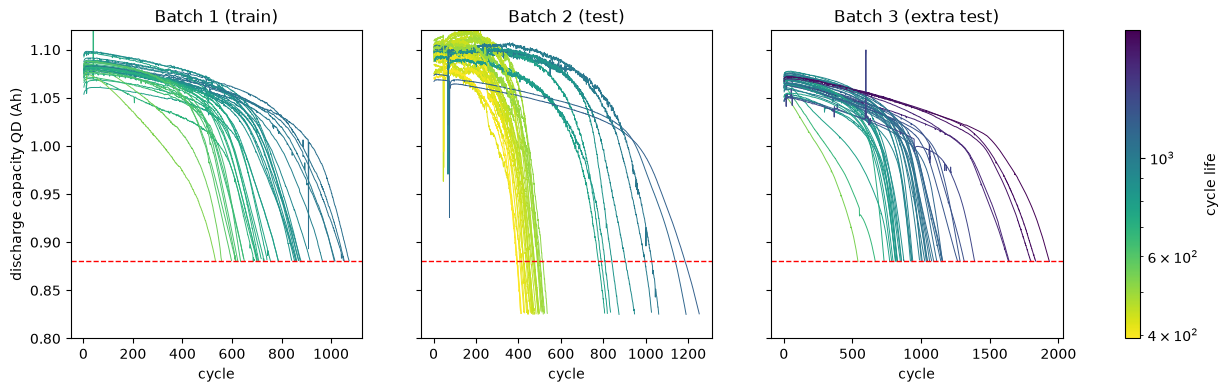

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, b in zip(axes, BATCHES):
    for cid, life in ok[ok.batch == b][['cell_id', 'cycle_life']].values:
        g = summary[(summary.cell_id == cid) & (summary.cycle >= 2)]
        ax.plot(g.cycle, g.QD, color=cmap(norm(life)), lw=.7)
    ax.axhline(0.88, color='r', ls='--', lw=1); ax.set_ylim(0.8, 1.12)
    ax.set_title(LABEL[b]); ax.set_xlabel('cycle')
axes[0].set_ylabel('discharge capacity QD (Ah)')
fig.colorbar(cm.ScalarMappable(norm, cmap), ax=axes, label='cycle life')
save(fig, '2_qd_curves')

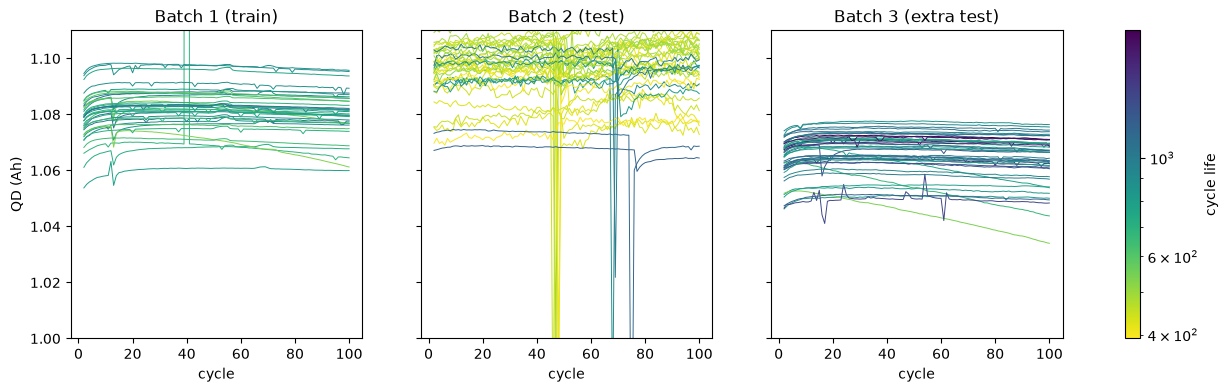

In [13]:
# 초기 100 사이클 확대 (모델 입력 구간)
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, b in zip(axes, BATCHES):
    for cid, life in ok[ok.batch == b][['cell_id', 'cycle_life']].values:
        g = summary[(summary.cell_id == cid) & summary.cycle.between(2, 100)]
        ax.plot(g.cycle, g.QD, color=cmap(norm(life)), lw=.7)
    ax.set_ylim(1.0, 1.11); ax.set_title(LABEL[b]); ax.set_xlabel('cycle')
axes[0].set_ylabel('QD (Ah)')
fig.colorbar(cm.ScalarMappable(norm, cmap), ax=axes, label='cycle life')
save(fig, '2_qd_first100')

In [14]:
def smooth_qd(cid, life):
    g = summary[(summary.cell_id == cid) & summary.cycle.between(2, life)].set_index('cycle').QD
    g = g[(g > 0.5) & (g < 1.2)]
    return g.rolling(25, center=True, min_periods=5).median().dropna()

def degradation(cid, life):
    s = smooth_qd(cid, life); x, y = s.index.values, s.values
    early = -np.polyfit(x[x <= 100], y[x <= 100], 1)[0]
    late = -np.polyfit(x[x >= life - 100], y[x >= life - 100], 1)[0]
    chord = y[0] + (y[-1] - y[0]) * (x - x[0]) / (x[-1] - x[0])
    return pd.Series({'fade_early(Ah/cyc)': early, 'fade_late(Ah/cyc)': late, 'knee': x[np.argmax(y - chord)]})

deg = ok[['batch', 'cell_id', 'cycle_life']].join(
    ok.apply(lambda r: degradation(r.cell_id, int(r.cycle_life)), axis=1))
# 초기 구간 용량이 오히려 증가(early<0)한 셀은 비율 정의 불가 → NaN
deg['late/early'] = (deg['fade_late(Ah/cyc)'] / deg['fade_early(Ah/cyc)']).where(deg['fade_early(Ah/cyc)'] > 0)
display(deg.assign(early_negative=deg['fade_early(Ah/cyc)'] <= 0).groupby('batch').early_negative.agg(['sum', 'size']))
deg['knee/life'] = deg.knee / deg.cycle_life
deg.groupby('batch')[['fade_early(Ah/cyc)', 'fade_late(Ah/cyc)', 'late/early', 'knee', 'knee/life']].median()

,sum,size
batch,,
b1,7,36
b2,22,39
b3,3,44


,fade_early(Ah/cyc),fade_late(Ah/cyc),late/early,knee,knee/life
batch,,,,,
b1,0.000013,0.000928,61.087443,550.0,0.706980
b2,-0.000018,0.001426,19.735181,323.0,0.684444
b3,0.000012,0.000888,60.925197,764.5,0.757302


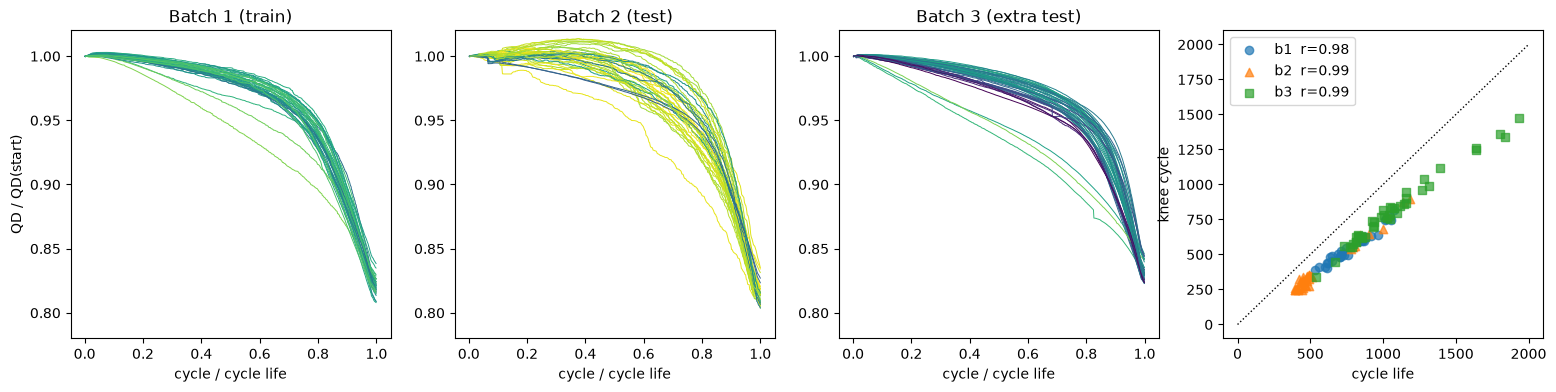

In [15]:
# 수명 대비 상대 위치로 정규화한 열화 곡선 + knee vs cycle life
fig, axes = plt.subplots(1, 4, figsize=(19, 4))
for ax, b in zip(axes, BATCHES):
    for cid, life in ok[ok.batch == b][['cell_id', 'cycle_life']].values:
        s = smooth_qd(cid, int(life))
        ax.plot(s.index / life, s.values / s.iloc[:5].median(), color=cmap(norm(life)), lw=.7)
    ax.set_title(LABEL[b]); ax.set_xlabel('cycle / cycle life'); ax.set_ylim(.78, 1.02)
axes[0].set_ylabel('QD / QD(start)')
for b, m in zip(BATCHES, 'o^s'):
    d = deg[deg.batch == b]
    axes[3].scatter(d.cycle_life, d.knee, marker=m, label=f'{b}  r={np.corrcoef(d.cycle_life, d.knee)[0, 1]:.2f}', alpha=.7)
axes[3].plot([0, 2000], [0, 2000], 'k:', lw=1); axes[3].set_xlabel('cycle life'); axes[3].set_ylabel('knee cycle'); axes[3].legend()
save(fig, '2_knee')

In [16]:
# 초기 100 사이클 용량 변화율 (cycle 2 → 100)
a = summary[summary.cycle.isin([2, 100])].pivot(index='cell_id', columns='cycle', values='QD')
chg = ((a[100] - a[2]) / a[2] * 100).rename('QD change 2→100 (%)')
print(f"전체 중앙값 : {chg[ok.cell_id].median():+.2f}%")
ok.join(chg, on='cell_id').groupby('batch')['QD change 2→100 (%)'].describe()[['50%', '25%', '75%', 'min', 'max']].round(2)

전체 중앙값 : +0.18%


,50%,25%,75%,min,max
batch,,,,,
b1,0.22,0.15,0.31,-1.06,0.62
b2,0.20,-0.09,0.63,-2.08,1.17
b3,0.13,0.03,0.21,-1.77,0.36


> **해석 / 시사점**
>
> - 초기 100 사이클 용량 변화는 중앙값 +0.18%로 거의 평탄 → 용량 값만으로는 장/단수명 구분 어려움
> - 말기 열화 속도는 초기의 약 60배(B1·B3 중앙값), knee는 수명의 약 70% 지점, knee–수명 상관 0.98 이상
> - 시사점 : 열화가 눈에 보이기 전(초기 100 사이클)의 미세 변화를 잡는 신호가 필요 → ΔQ(V)

## 3. ΔQ(V) 곡선 — 초기 사이클에서 차이가 보이는가?

- ΔQ_100-10(V) = Q_100(V) − Q_10(V) : 같은 전압에서 방전 용량이 90사이클 동안 얼마나 변했는가 (Qdlin, 3.5→2.0V, 1000점)

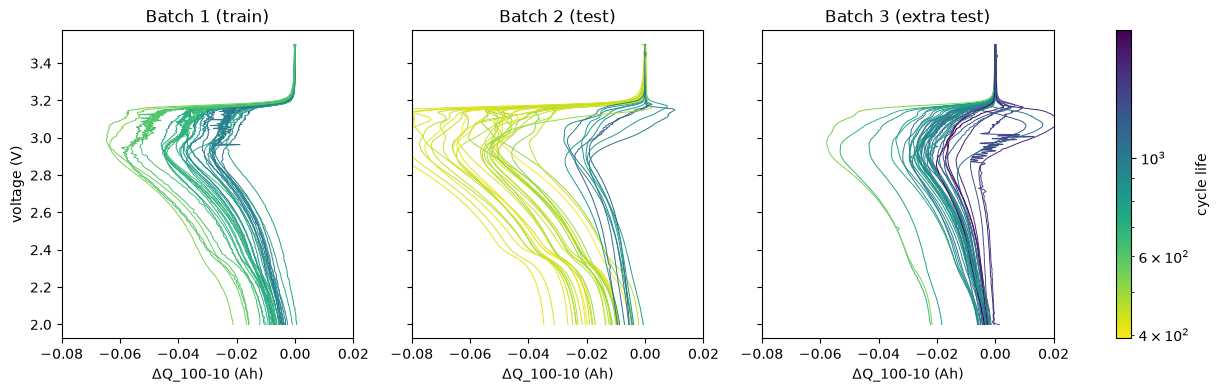

In [17]:
dq = F.delta_q(qdlin)
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, b in zip(axes, BATCHES):
    for cid, life in ok[ok.batch == b][['cell_id', 'cycle_life']].values:
        ax.plot(dq[idx[cid]], vdlin, color=cmap(norm(life)), lw=.7)
    ax.set_xlim(-0.08, 0.02); ax.set_xlabel('ΔQ_100-10 (Ah)'); ax.set_title(LABEL[b])
axes[0].set_ylabel('voltage (V)')
fig.colorbar(cm.ScalarMappable(norm, cmap), ax=axes, label='cycle life')
save(fig, '3_delta_q_curves')

dQ_log_var  dQ_log_min  dQ_log_mean  dQ_log_skew  dQ_log_kurt
batch life_grp                                                                  
b1    mid              -3.769      -1.404       -1.745       -0.817        0.102
      long(>1000)      -4.059      -1.542       -1.908       -0.636        0.090
b2    short(<500)      -3.446      -1.250       -1.543       -0.737        0.094
      mid              -4.153      -1.568       -1.952       -0.659        0.016
      long(>1000)      -4.272      -1.717       -2.090       -0.544       -0.052
b3    mid              -4.092      -1.558       -1.929       -0.523        0.073
      long(>1000)      -4.317      -1.696       -2.061       -0.534        0.062

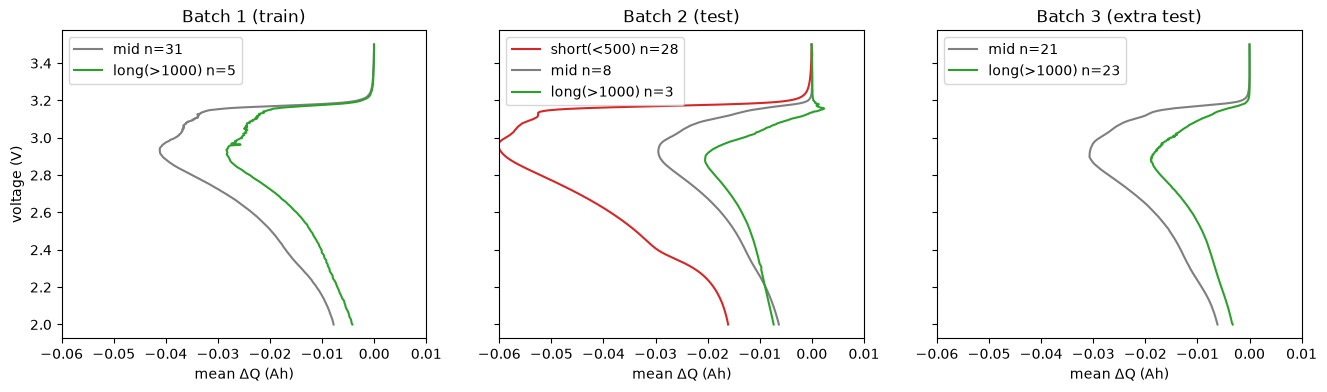

In [18]:
# 장/중/단수명 그룹별 평균 ΔQ 곡선
ok['life_grp'] = pd.cut(ok.cycle_life, [0, 500, 1000, 5000], labels=['short(<500)', 'mid', 'long(>1000)'])
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, b in zip(axes, BATCHES):
    for grp, c in zip(['short(<500)', 'mid', 'long(>1000)'], ['tab:red', 'tab:gray', 'tab:green']):
        g = ok[(ok.batch == b) & (ok.life_grp == grp)]
        if len(g):
            ax.plot(dq[[idx[c_] for c_ in g.cell_id]].mean(0), vdlin, color=c, label=f'{grp} n={len(g)}')
    ax.set_xlim(-0.06, 0.01); ax.set_title(LABEL[b]); ax.set_xlabel('mean ΔQ (Ah)'); ax.legend()
axes[0].set_ylabel('voltage (V)')
save(fig, '3_delta_q_groups')
DQ = ['dQ_log_var', 'dQ_log_min', 'dQ_log_mean', 'dQ_log_skew', 'dQ_log_kurt']
ok.groupby(['batch', 'life_grp'], observed=True)[DQ].median().round(3)

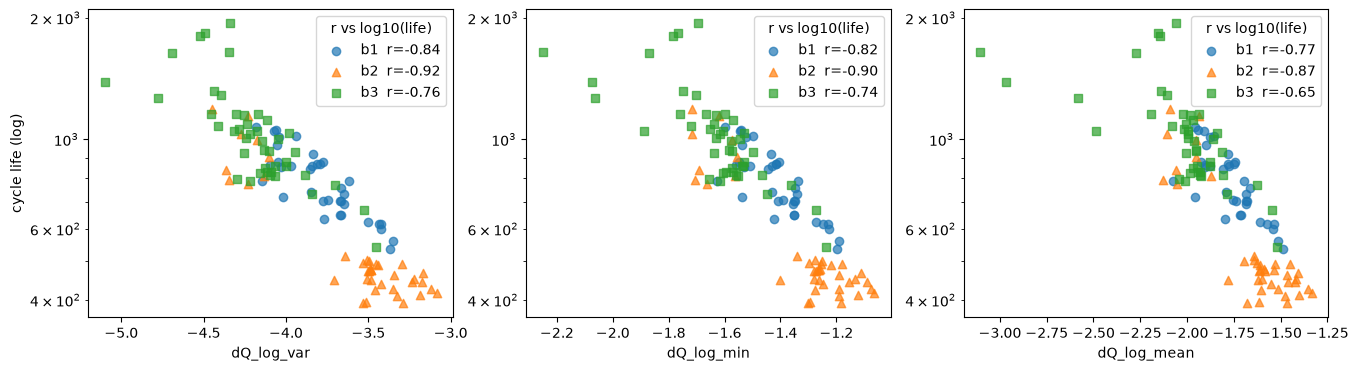

In [19]:
# 핵심 통계값 vs cycle life (배치 공통 관계인가?)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, f in zip(axes, ['dQ_log_var', 'dQ_log_min', 'dQ_log_mean']):
    for b, m in zip(BATCHES, 'o^s'):
        g = ok[ok.batch == b]
        ax.scatter(g[f], g.cycle_life, marker=m, alpha=.7, label=f'{b}  r={np.corrcoef(g[f], g.log_life)[0, 1]:.2f}')
    ax.set_yscale('log'); ax.set_xlabel(f); ax.legend(title='r vs log10(life)')
axes[0].set_ylabel('cycle life (log)')
save(fig, '3_delta_q_features')

In [20]:
# 사이클 정렬 확인 : b2·b3는 cycle 1부터 고속 사이클 → b1 기준 '같은 고속 사이클'은 (9, 99)
rows = {}
for b in ['b2', 'b3']:
    g = ok[ok.batch == b]; ii = [idx[c] for c in g.cell_id]
    v_10_100 = np.log10(np.var(F.delta_q(qdlin, 10, 100)[ii], axis=1))
    v_9_99 = np.log10(np.var(F.delta_q(qdlin, 9, 99)[ii], axis=1))
    rows[b] = {'mean shift (9,99)-(10,100)': (v_9_99 - v_10_100).mean(),
               'r with log life (10,100)': np.corrcoef(v_10_100, g.log_life)[0, 1],
               'r with log life (9,99)': np.corrcoef(v_9_99, g.log_life)[0, 1]}
pd.DataFrame(rows).round(4)

,b2,b3
"mean shift (9,99)-(10,100)",-0.0250,-0.0081
"r with log life (10,100)",-0.9184,-0.7621
"r with log life (9,99)",-0.9051,-0.7843


In [21]:
# ΔQ가 가장 크게 벌어지는 전압 (min ΔQ 위치)
v_at_min = pd.Series(vdlin[np.argmin(dq, axis=1)], index=ids)
print(f"전체 중앙값 : {v_at_min[ok.cell_id].median():.3f} V")
ok.assign(v_at_min=v_at_min[ok.cell_id].values).groupby('batch').v_at_min.median().round(3)

전체 중앙값 : 2.926 V


batch
b1    2.935
b2    2.959
b3    2.905
Name: v_at_min, dtype: float64

> **해석 / 시사점**
>
> - 단수명 셀일수록 ΔQ 곡선이 크게 벌어짐 (차이 최대 지점 약 2.9V)
> - log 분산–log 수명 상관 B1 -0.84 / B2 -0.92 / B3 -0.76 → 세 배치 모두 같은 방향 → 핵심 피처
> - var / min / mean은 사실상 같은 정보(섹션 5) → 1개만 사용
> - B2·B3의 1사이클 정렬 차이 : log 분산 이동 0.03 이하, 상관 변화 미미 → 정렬 보정 없이 사용

## 4. 충전 조건 (C-rate)과 수명의 관계는?

- 정책 `C1(Q1%)-C2` : SOC 0→Q1%를 C1, Q1→80%를 C2로 충전. 이후 1C CC-CV
- `crate_avg_0_80` = 0→80% 평균 C-rate (정책에서 계산), `chargetime_2_6` = 측정된 충전시간 (cycle 2~6 평균, 분)

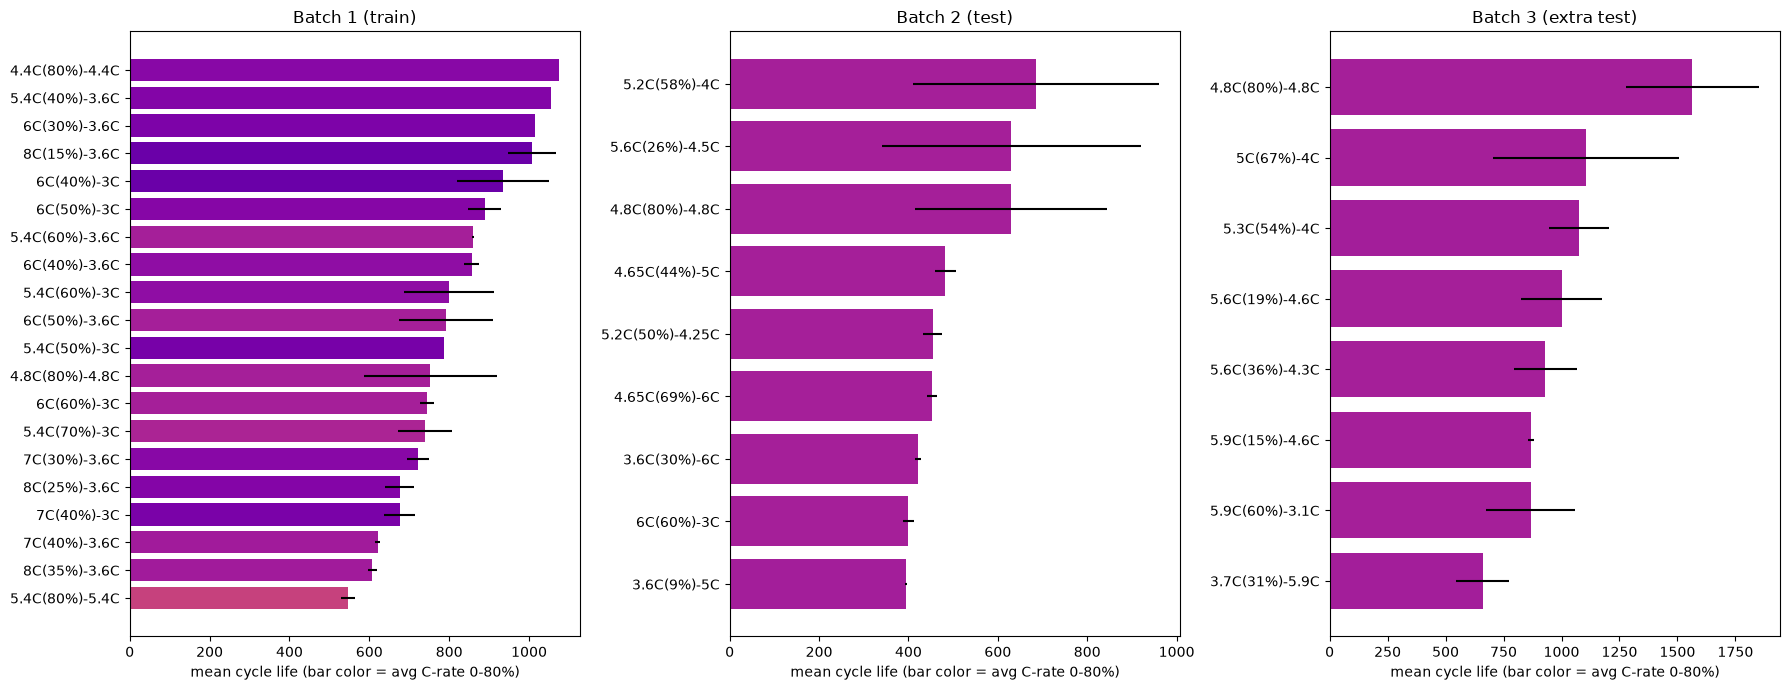

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, b in zip(axes, BATCHES):
    g = ok[ok.batch == b].groupby('policy').agg(mean=('cycle_life', 'mean'), std=('cycle_life', 'std'),
                                                 n=('cycle_life', 'size'), crate=('crate_avg_0_80', 'first'))
    g = g.sort_values('mean')
    ax.barh(g.index, g['mean'], xerr=g['std'].fillna(0), color=cm.plasma(colors.Normalize(3, 8)(g.crate)))
    ax.set_title(LABEL[b]); ax.set_xlabel('mean cycle life (bar color = avg C-rate 0-80%)')
fig.tight_layout()
save(fig, '4_policy_life')

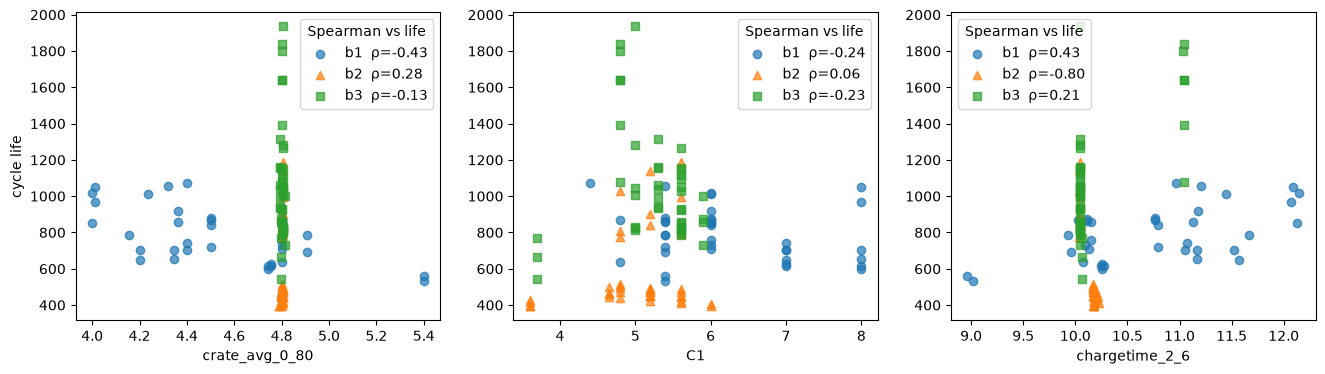

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, f in zip(axes, ['crate_avg_0_80', 'C1', 'chargetime_2_6']):
    for b, m in zip(BATCHES, 'o^s'):
        g = ok[ok.batch == b].dropna(subset=[f])
        ax.scatter(g[f], g.cycle_life, marker=m, alpha=.7, label=f'{b}  ρ={spearmanr(g[f], g.cycle_life)[0]:.2f}')
    ax.set_xlabel(f); ax.legend(title='Spearman vs life')
axes[0].set_ylabel('cycle life')
save(fig, '4_crate_scatter')

In [24]:
# 충전 조건 ↔ 수명 / 초기 열화 속도 상관 (Spearman)
CH = ['C1', 'Q1', 'C2', 'crate_avg_0_80', 'chargetime_2_6', 'Tavg_mean', 'Tmax_max']
rows = {}
for b in BATCHES:
    g = ok[ok.batch == b]
    for tgt in ['cycle_life', 'fade_slope_2_100']:
        rows[(b, tgt)] = {f: spearmanr(g[f], g[tgt], nan_policy='omit')[0] for f in CH}
pd.DataFrame(rows).round(2)

b1                          b2                          b3                 
               cycle_life fade_slope_2_100 cycle_life fade_slope_2_100 cycle_life fade_slope_2_100
C1                  -0.24            -0.23       0.06            -0.07      -0.23            -0.09
Q1                  -0.06            -0.06       0.29             0.02       0.44             0.38
C2                  -0.16            -0.15      -0.12            -0.13       0.02            -0.20
crate_avg_0_80      -0.43            -0.44       0.28            -0.42      -0.13            -0.07
chargetime_2_6       0.43             0.45      -0.80             0.03       0.21            -0.10
Tavg_mean           -0.12            -0.06       0.17            -0.18       0.03            -0.52
Tmax_max            -0.10             0.12      -0.15             0.03      -0.04            -0.48

In [25]:
# Batch 2 : 정책상 0→80% 충전시간은 모두 10분인데, 측정 충전시간(cycle 2~6)은 셀마다 다름 → 원시값 확인
b2 = ok[ok.batch == 'b2'].sort_values('cycle_life', ascending=False)
display(b2[['cell_id', 'policy', 'cycle_life', 't80_min', 'chargetime_2_6', 'Tavg_mean', 'IR_min']].head(12))
b2.groupby('life_grp', observed=True)[['chargetime_2_6', 't80_min']].describe().round(3)

,cell_id,policy,cycle_life,t80_min,chargetime_2_6,Tavg_mean,IR_min
80,b2c34,5.6C(26%)-4.5C,1186.0,9.985714,10.040011,35.667891,0.014872
79,b2c33,5.2C(58%)-4C,1140.0,9.992308,10.039203,32.741571,0.014933
89,b2c43,4.8C(80%)-4.8C,1029.0,10.000000,10.036202,33.929145,NaN
91,b2c45,5.6C(26%)-4.5C,997.0,9.985714,10.040268,35.271412,NaN
54,b2c8,5.2C(58%)-4C,904.0,9.992308,10.040079,33.598684,0.016342
90,b2c44,5.2C(58%)-4C,841.0,9.992308,10.040366,33.959958,NaN
78,b2c32,4.8C(80%)-4.8C,809.0,10.000000,10.041901,32.168949,0.014739
55,b2c9,5.6C(26%)-4.5C,791.0,9.985714,10.040581,32.350853,0.015197
53,b2c7,4.8C(80%)-4.8C,777.0,10.000000,10.037040,33.769687,0.014717
70,b2c24,4.8C(80%)-4.8C,514.0,10.000000,10.170491,33.206377,0.016424


chargetime_2_6                                                        t80_min                                                   
                     count    mean    std     min     25%     50%     75%     max   count   mean    std    min    25%     50%     75%    max
life_grp                                                                                                                                    
short(<500)           28.0  10.182  0.015  10.171  10.174  10.175  10.179  10.224    28.0  9.998  0.009  9.986  9.992  10.000  10.004  10.02
mid                    8.0  10.073  0.060  10.037  10.040  10.040  10.074  10.170     8.0  9.995  0.006  9.986  9.991   9.996  10.000  10.00
long(>1000)            3.0  10.038  0.002  10.036  10.038  10.039  10.040  10.040     3.0  9.993  0.007  9.986  9.989   9.992   9.996  10.00

In [26]:
# 같은 정책 안에서의 차이 : 정책 평균을 뺀 뒤 log 수명과 상관 (정책당 2셀 이상)
rows = {}
for b in BATCHES:
    g = ok[ok.batch == b]
    g = g[g.groupby('policy').cell_id.transform('size') >= 2]
    cols = ['QD_2', 'Tavg_mean', 'dQ_log_var', 'log_life']
    d = g[cols] - g.groupby('policy')[cols].transform('mean')
    rows[b] = {c: d[c].corr(d.log_life) for c in cols[:-1]}
pd.DataFrame(rows).round(2)

,b1,b2,b3
QD_2,0.73,-0.48,0.28
Tavg_mean,-0.38,0.50,0.31
dQ_log_var,-0.10,-0.94,-0.44


> **해석 / 시사점**
>
> - B1은 평균 C-rate가 높을수록 수명이 짧음(ρ -0.43). B2·B3는 모든 정책이 10분 충전이라 평균 C-rate가 사실상 같음
> - 같은 정책 내에서 초기 용량이 클수록 길고(B1 r +0.73), 셀 온도가 높을수록 짧음(B1 r -0.38) → 셀 차이와 온도 차이가 함께 작용하는 것으로 추정
> - B2 측정 충전시간이 10.04분(9셀, 수명 777~1,186) / 10.17분(30셀, 수명 392~514)으로 갈림. 같은 정책이 양쪽에 있어 정책이 아닌 시험 조건 차이로 추정 (원인은 데이터로 확정 불가)
> - 시사점 : 충전 조건 피처만으로는 수명 예측 불충분

## 5. 상관관계 — 어떤 신호가 수명과 연관되어 있는가?

- 초기 100 사이클 피처 vs log10(cycle life) 상관, 피처 간 다중공선성(상관행렬, VIF)

b1               b2               b3         
                  pearson spearman pearson spearman pearson spearman
dQ_log_var          -0.84    -0.83   -0.92    -0.71   -0.76    -0.80
dQ_log_min          -0.82    -0.79   -0.90    -0.66   -0.74    -0.78
dQ_log_mean         -0.77    -0.76   -0.87    -0.70   -0.65    -0.76
crate_avg_0_80      -0.59    -0.43    0.35     0.28   -0.02    -0.13
chargetime_2_6       0.57     0.43   -0.94    -0.80    0.60     0.21
QD_100_minus_10      0.55     0.49   -0.15    -0.05    0.43     0.03
fade_slope_91_100    0.44     0.32    0.27     0.35    0.38     0.01
fade_slope_2_100     0.38     0.47   -0.42    -0.27    0.43     0.09
IR_min               0.34     0.24   -0.57    -0.20    0.17     0.13
dQ_log_skew          0.27     0.28    0.25     0.22   -0.02    -0.00
QD_2                 0.16     0.16   -0.23     0.08    0.17     0.13
Tavg_mean           -0.16    -0.12    0.39     0.17   -0.01     0.03
IR_100_minus_2       0.14    -0.23    0.36     0.31   -0.46    -0.16
fade_icpt_91_100     0.12     0.11   -0.41    -0.27    0.16     0.13
Tmax_max            -0.10    -0.10   -0.05    -0.15   -0.09    -0.04
QD_max_minus_2      -0.10     0.29   -0.31    -0.18    0.13    -0.18
fade_icpt_2_100      0.08     0.07   -0.14     0.18    0.14     0.09
dQ_log_kurt         -0.00    -0.24   -0.66    -0.50    0.26    -0.02

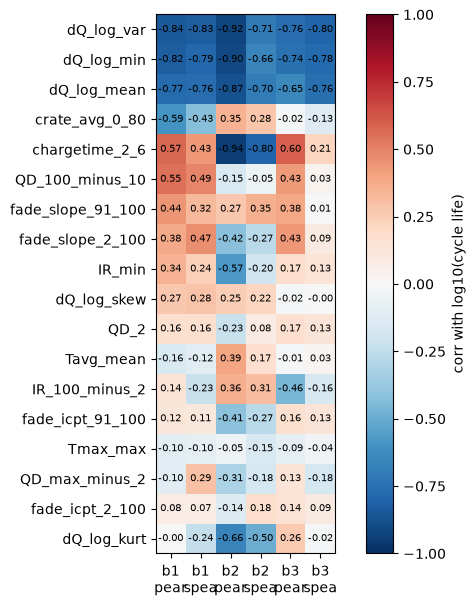

In [27]:
FEATS = ['dQ_log_var', 'dQ_log_min', 'dQ_log_mean', 'dQ_log_skew', 'dQ_log_kurt',
         'QD_2', 'QD_max_minus_2', 'QD_100_minus_10', 'fade_slope_2_100', 'fade_icpt_2_100',
         'fade_slope_91_100', 'fade_icpt_91_100', 'chargetime_2_6', 'Tavg_mean', 'Tmax_max',
         'IR_min', 'IR_100_minus_2', 'crate_avg_0_80']
corr = pd.DataFrame({(b, m): [ (ok[ok.batch == b][f].corr(ok[ok.batch == b].log_life, method=m)) for f in FEATS]
                     for b in BATCHES for m in ['pearson', 'spearman']}, index=FEATS)
corr = corr.reindex(corr[('b1', 'pearson')].abs().sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(corr.shape[1]), [f'{b}\n{m[:4]}' for b, m in corr.columns]); ax.set_yticks(range(len(corr)), corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, label='corr with log10(cycle life)')
save(fig, '5_corr_target')
corr.round(2)

dQ_log_var        dQ_log_min           0.996
chargetime_2_6    crate_avg_0_80      -0.995
dQ_log_min        dQ_log_mean          0.990
dQ_log_var        dQ_log_mean          0.980
QD_max_minus_2    IR_100_minus_2      -0.976
QD_2              fade_icpt_91_100     0.969
QD_100_minus_10   fade_slope_91_100    0.916
Tavg_mean         Tmax_max             0.909
fade_slope_2_100  IR_100_minus_2       0.872
QD_max_minus_2    fade_slope_2_100    -0.846
fade_icpt_2_100   fade_icpt_91_100     0.807
QD_2              fade_icpt_2_100      0.804
dtype: float64

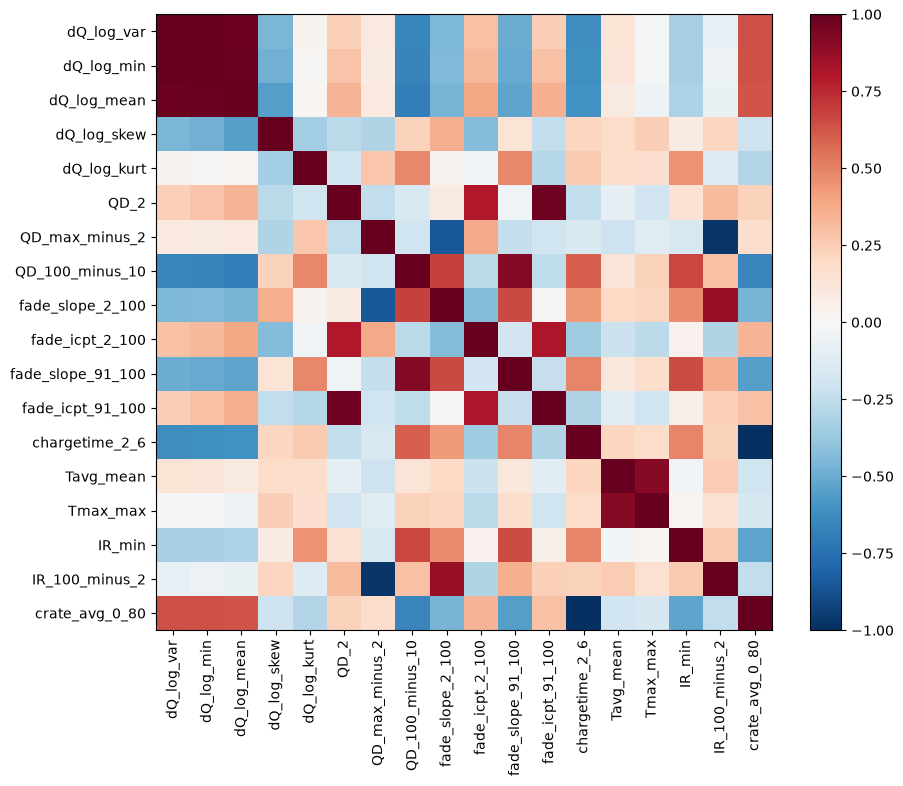

In [28]:
# 피처 간 상관 (Batch 1)
fc = ok[ok.batch == 'b1'][FEATS].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(fc, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATS)), FEATS, rotation=90); ax.set_yticks(range(len(FEATS)), FEATS)
fig.colorbar(im); save(fig, '5_corr_features_b1')
pairs = fc.where(np.triu(np.ones(fc.shape, bool), 1)).stack()
pairs[pairs.abs() > 0.8].sort_values(key=abs, ascending=False).round(3)

In [29]:
# VIF (Batch 1, IR 결측 없음) : VIF_i = 1 / (1 - R²_i),  R²_i = 피처 i를 나머지로 회귀한 결정계수
X = ok[ok.batch == 'b1'][FEATS].dropna()
X = (X - X.mean()) / X.std()
vif = {f: 1 / max(1e-9, 1 - LinearRegression().fit(X.drop(columns=f), X[f]).score(X.drop(columns=f), X[f])) for f in FEATS}
pd.Series(vif).sort_values(ascending=False).round(1)

fade_icpt_91_100     26208.1
fade_icpt_2_100      25743.8
fade_slope_2_100      6604.5
fade_slope_91_100     6407.8
QD_max_minus_2        2145.8
dQ_log_min            1506.5
QD_2                  1480.5
dQ_log_var            1101.2
crate_avg_0_80         353.0
dQ_log_mean            352.3
chargetime_2_6         319.0
QD_100_minus_10        305.3
IR_100_minus_2         283.8
Tmax_max                19.4
Tavg_mean               19.2
dQ_log_kurt              7.5
dQ_log_skew              5.9
IR_min                   5.8
dtype: float64

> **해석 / 시사점**
>
> - B1에서 수명과 상관 1위는 dQ_log_var(-0.84)
> - 충전시간–수명 상관이 B1 +0.57 / B2 -0.94로 방향이 뒤집힘 → B1에서 배운 관계가 B2에서 성립하지 않음
> - ΔQ 통계끼리 상관 0.98~0.996, VIF 최대 약 2.6만 → 피처를 늘려도 새 정보는 적고 계수만 불안정

## 6. 배치 간 분포 차이 (Train → Test 이동)

- 주요 피처의 배치별 분포 + Batch 1 대비 KS 검정 (p < 0.05 → 분포 다름)

,KS p (b1 vs b2),KS p (b1 vs b3)
cycle_life,0.0000,0.0002
dQ_log_var,0.0000,0.0000
dQ_log_min,0.0000,0.0000
QD_2,0.0000,0.0000
fade_slope_2_100,0.0010,0.3850
chargetime_2_6,0.0000,0.0000
Tavg_mean,0.4153,0.0000
IR_min,0.1990,0.0000


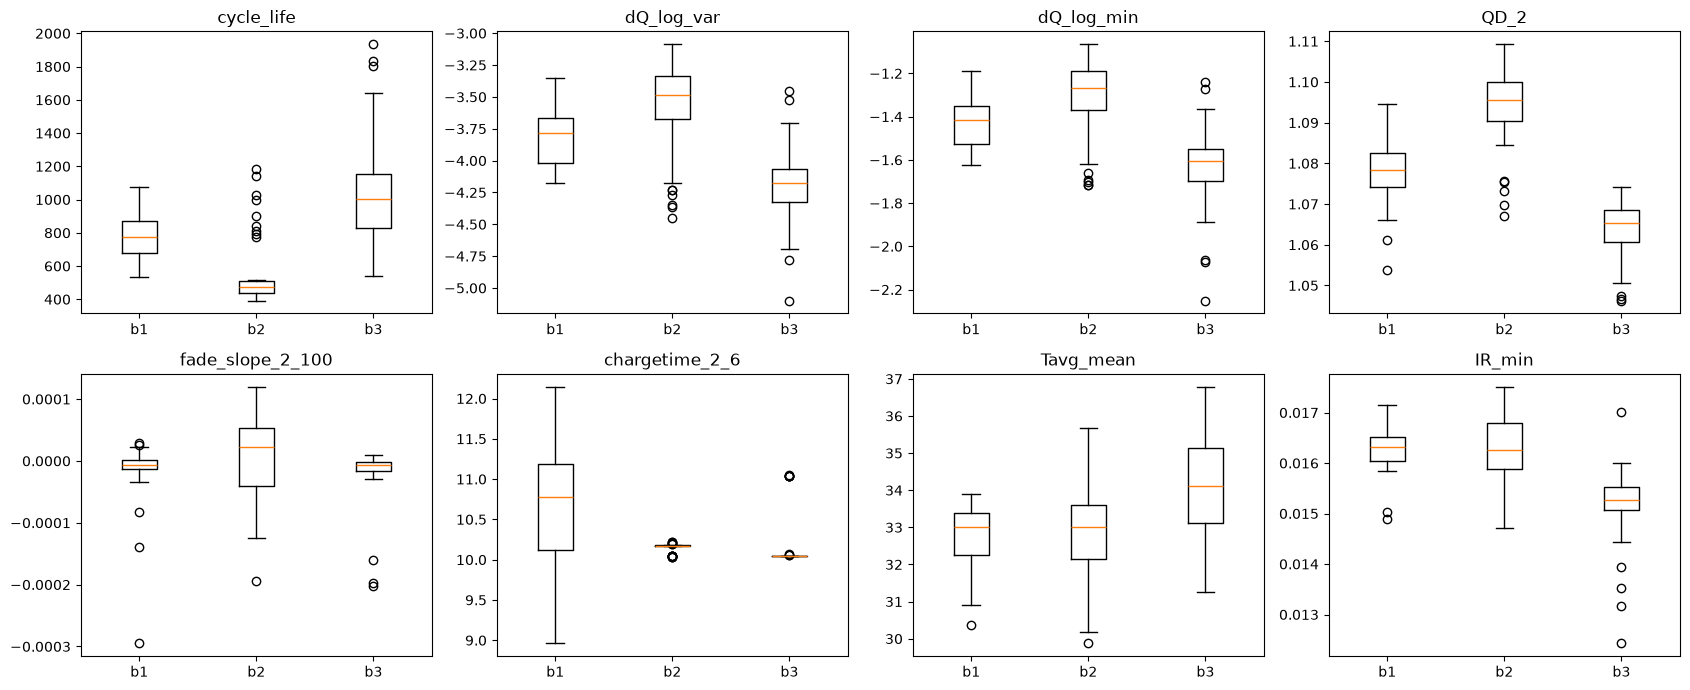

In [30]:
KEY = ['cycle_life', 'dQ_log_var', 'dQ_log_min', 'QD_2', 'fade_slope_2_100', 'chargetime_2_6', 'Tavg_mean', 'IR_min']
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for ax, f in zip(axes.ravel(), KEY):
    ax.boxplot([ok[ok.batch == b][f].dropna() for b in BATCHES], tick_labels=BATCHES); ax.set_title(f)
fig.tight_layout(); save(fig, '6_batch_shift')
b1 = ok[ok.batch == 'b1']
pd.DataFrame({f'KS p (b1 vs {b})': {f: ks_2samp(b1[f].dropna(), ok[ok.batch == b][f].dropna()).pvalue for f in KEY}
              for b in ['b2', 'b3']}).round(4)

> **해석 / 시사점**
>
> - 초기 용량·충전시간은 B2·B3 모두 B1과 분포가 다름(KS p≈0), 온도·IR은 B3에서만 다름
> - dQ_log_var도 분포는 다르지만(수명 분포가 다르므로 당연) 수명과의 관계 방향은 유지됨(섹션 3)
> - 시사점 : 피처 선택 기준은 '분포가 같은가'보다 '수명과의 관계 방향이 배치 간 유지되는가'

## 7. 모델 전략 결정

| 항목 | 결정 | 근거 (EDA 섹션) |
|---|---|---|
| 제외 셀 처리 | 라벨을 믿을 수 없는 셀 제외 유지 | 라벨 ≠ 실제 수명 (0) |
| Target 변환 | log10(cycle_life) | ΔQ와 log 수명 직선 관계 (3), CV·Valid는 원래 값과 동률 |
| 사용 피처 | dQ_log_var 1개 | B1 상관 1위, 세 배치 모두 같은 방향 (3·5) |
| 다중공선성 대응 | 피처 1개로 회피 | ΔQ 통계끼리 상관 0.98+, VIF 수천 (5) |
| 후보 모델 | Ridge · ElasticNet · SVR · RF · GBR → 1-SE 규칙으로 선택 | 학습 셀 29개라 CV 차이가 표준오차 안이면 단순한 모델 |
| B2·B3 사이클 정렬 | (10, 100) 그대로 | 정렬 차이 영향 미미 (3) |
| 배치 간 차이 대응 | 관계 방향이 배치 간 유지되는 피처만 사용 | 충전시간 등은 관계 방향이 뒤집힘 (4·5·6) |